In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score



In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("taweilo/taiwan-air-quality-data-20162024")

print("Path to dataset files:", path)

100%|██████████| 172M/172M [00:52<00:00, 3.41MB/s] 

Extracting files...


Path to dataset files: C:\Users\Dareen\.cache\kagglehub\datasets\taweilo\taiwan-air-quality-data-20162024\versions\1


In [3]:
df= pd.read_csv(path + "/air_quality.csv")
df.head()

C:\Users\Dareen\AppData\Local\Temp\ipykernel_16216\884840921.py:1: DtypeWarning: Columns (6,7,8,9,10,11,12,13,14,15,16,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(path + "/air_quality.csv")


,date,sitename,county,aqi,pollutant,status,so2,co,o3,o3_8hr,...,windspeed,winddirec,unit,co_8hr,pm2.5_avg,pm10_avg,so2_avg,longitude,latitude,siteid
0,2024-08-31 23:00,Hukou,Hsinchu County,62.0,PM2.5,Moderate,0.9,0.17,35.0,40.2,...,2.3,225,NaN,0.2,20.1,26.0,1.0,121.038869,24.900097,22.0
1,2024-08-31 23:00,Zhongming,Taichung City,50.0,NaN,Good,1.6,0.32,27.9,35.1,...,1.1,184,NaN,0.2,15.3,23.0,1.0,120.641092,24.151958,31.0
2,2024-08-31 23:00,Zhudong,Hsinchu County,45.0,NaN,Good,0.4,0.17,25.1,40.6,...,0.4,210,NaN,0.2,13.8,24.0,0.0,121.088955,24.740914,23.0
3,2024-08-31 23:00,Hsinchu,Hsinchu City,42.0,NaN,Good,0.8,0.2,30.0,35.9,...,1.9,239,NaN,0.2,13.0,26.0,1.0,120.972368,24.805636,24.0
4,2024-08-31 23:00,Toufen,Miaoli County,50.0,NaN,Good,1.0,0.16,33.5,35.9,...,1.8,259,NaN,0.1,15.3,28.0,1.0,120.898693,24.696907,25.0


In [48]:
df.shape

(5882208, 25)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5882208 entries, 0 to 5882207
Data columns (total 25 columns):
 #   Column     Dtype  
---  ------     -----  
 0   date       object 
 1   sitename   object 
 2   county     object 
 3   aqi        float64
 4   pollutant  object 
 5   status     object 
 6   so2        object 
 7   co         object 
 8   o3         object 
 9   o3_8hr     object 
 10  pm10       object 
 11  pm2.5      object 
 12  no2        object 
 13  nox        object 
 14  no         object 
 15  windspeed  object 
 16  winddirec  object 
 17  unit       float64
 18  co_8hr     object 
 19  pm2.5_avg  object 
 20  pm10_avg   object 
 21  so2_avg    object 
 22  longitude  float64
 23  latitude   float64
 24  siteid     float64
dtypes: float64(5), object(20)
memory usage: 1.1+ GB


In [50]:
df.describe()

,aqi,unit,longitude,latitude,siteid
count,5.839188e+06,0.0,4.948588e+06,4.948588e+06,4.102739e+06
mean,5.419277e+01,NaN,1.208235e+02,2.404500e+01,5.608608e+01
std,2.985864e+01,NaN,9.644120e-01,1.002014e+00,6.233482e+01
min,-1.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.200000e+01,NaN,1.203455e+02,2.304820e+01,2.100000e+01
50%,4.600000e+01,NaN,1.206853e+02,2.415196e+01,4.200000e+01
75%,7.000000e+01,NaN,1.214492e+02,2.501297e+01,6.500000e+01
max,5.000000e+02,NaN,1.218157e+02,2.625800e+01,3.140000e+02


# Duplicate

In [51]:
df.duplicated().sum()

0

# Drop useless columns

In [52]:
df.drop(columns="unit", inplace=True)

# Clean Column Names

In [53]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(".", "_")
)

# Type conversion

In [54]:
df["date"] = pd.to_datetime(df["date"],errors="coerce")

In [55]:
# Mariam Gamal
numeric_columns = [
    "aqi",
    "so2",
    "co",
    "o3",
    "pm10",
    "pm2_5",
    "no2",
    "nox",
    "no",
    "windspeed",
    "winddirec",
    "so2_avg",
    "pm2_5_avg",
    "o3_8hr",
    "pm10_avg",
    "co_8hr",
    "pm2_5_avg"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [56]:
# Mariam Gamal
measurement_columns = [
    "aqi",
    "so2",
    "co",
    "o3",
    "pm10",
    "pm2_5",
    "no2",
    "nox",
    "no",
    "windspeed",
    "winddirec",
    "so2_avg",
    "pm2_5_avg",
    "o3_8hr",
    "pm10_avg",
    "co_8hr",
    "pm2_5_avg"
]

for col in measurement_columns:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5882208 entries, 0 to 5882207
Data columns (total 24 columns):
 #   Column     Dtype         
---  ------     -----         
 0   date       datetime64[ns]
 1   sitename   object        
 2   county     object        
 3   aqi        float64       
 4   pollutant  object        
 5   status     object        
 6   so2        float64       
 7   co         float64       
 8   o3         float64       
 9   o3_8hr     float64       
 10  pm10       float64       
 11  pm2_5      float64       
 12  no2        float64       
 13  nox        float64       
 14  no         float64       
 15  windspeed  float64       
 16  winddirec  float64       
 17  co_8hr     float64       
 18  pm2_5_avg  float64       
 19  pm10_avg   float64       
 20  so2_avg    float64       
 21  longitude  float64       
 22  latitude   float64       
 23  siteid     float64       
dtypes: datetime64[ns](1), float64(19), object(4)
memory usage: 1.1+ GB


# Missing(Mariam Gamal)

In [58]:
round(df.isnull().sum().sort_values(ascending=False)*100/len(df), 2)

pollutant    55.00
siteid       30.25
latitude     15.87
longitude    15.87
so2_avg      10.70
winddirec     5.15
windspeed     5.15
o3            3.53
pm2_5         3.44
no            3.38
nox           2.88
no2           2.84
co            2.63
o3_8hr        2.61
so2           2.51
pm10          2.49
status        2.43
co_8hr        1.76
pm10_avg      1.64
pm2_5_avg     1.36
aqi           0.86
date          0.00
sitename      0.00
county        0.00
dtype: float64

In [59]:
df.drop(columns="pollutant", inplace=True)

In [60]:
df["siteid"]=df.index + 1

In [61]:
for col in  ["so2","no","nox","no2","o3","pm2_5","pm10","co","so2_avg","pm2_5_avg","o3_8hr","pm10_avg","co_8hr","aqi"]:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\Dareen\AppData\Local\Temp\ipykernel_9276\1177011225.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\Dareen\AppData\Local\Temp\ipykernel_9276\1177011225.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [62]:
for col in  ["status","winddirec","windspeed"]:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\Dareen\AppData\Local\Temp\ipykernel_9276\736207649.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [63]:
round(df.isnull().sum().sort_values(ascending=False)*100/len(df), 2)

latitude     15.87
longitude    15.87
date          0.00
nox           0.00
so2_avg       0.00
pm10_avg      0.00
pm2_5_avg     0.00
co_8hr        0.00
winddirec     0.00
windspeed     0.00
no            0.00
no2           0.00
sitename      0.00
pm2_5         0.00
pm10          0.00
o3_8hr        0.00
o3            0.00
co            0.00
so2           0.00
status        0.00
aqi           0.00
county        0.00
siteid        0.00
dtype: float64

# Outliers (Darin Ashraf)

In [64]:
num_cols = df.select_dtypes(include="number").columns
num_cols = num_cols.drop(["siteid","latitude","longitude"], errors="ignore")

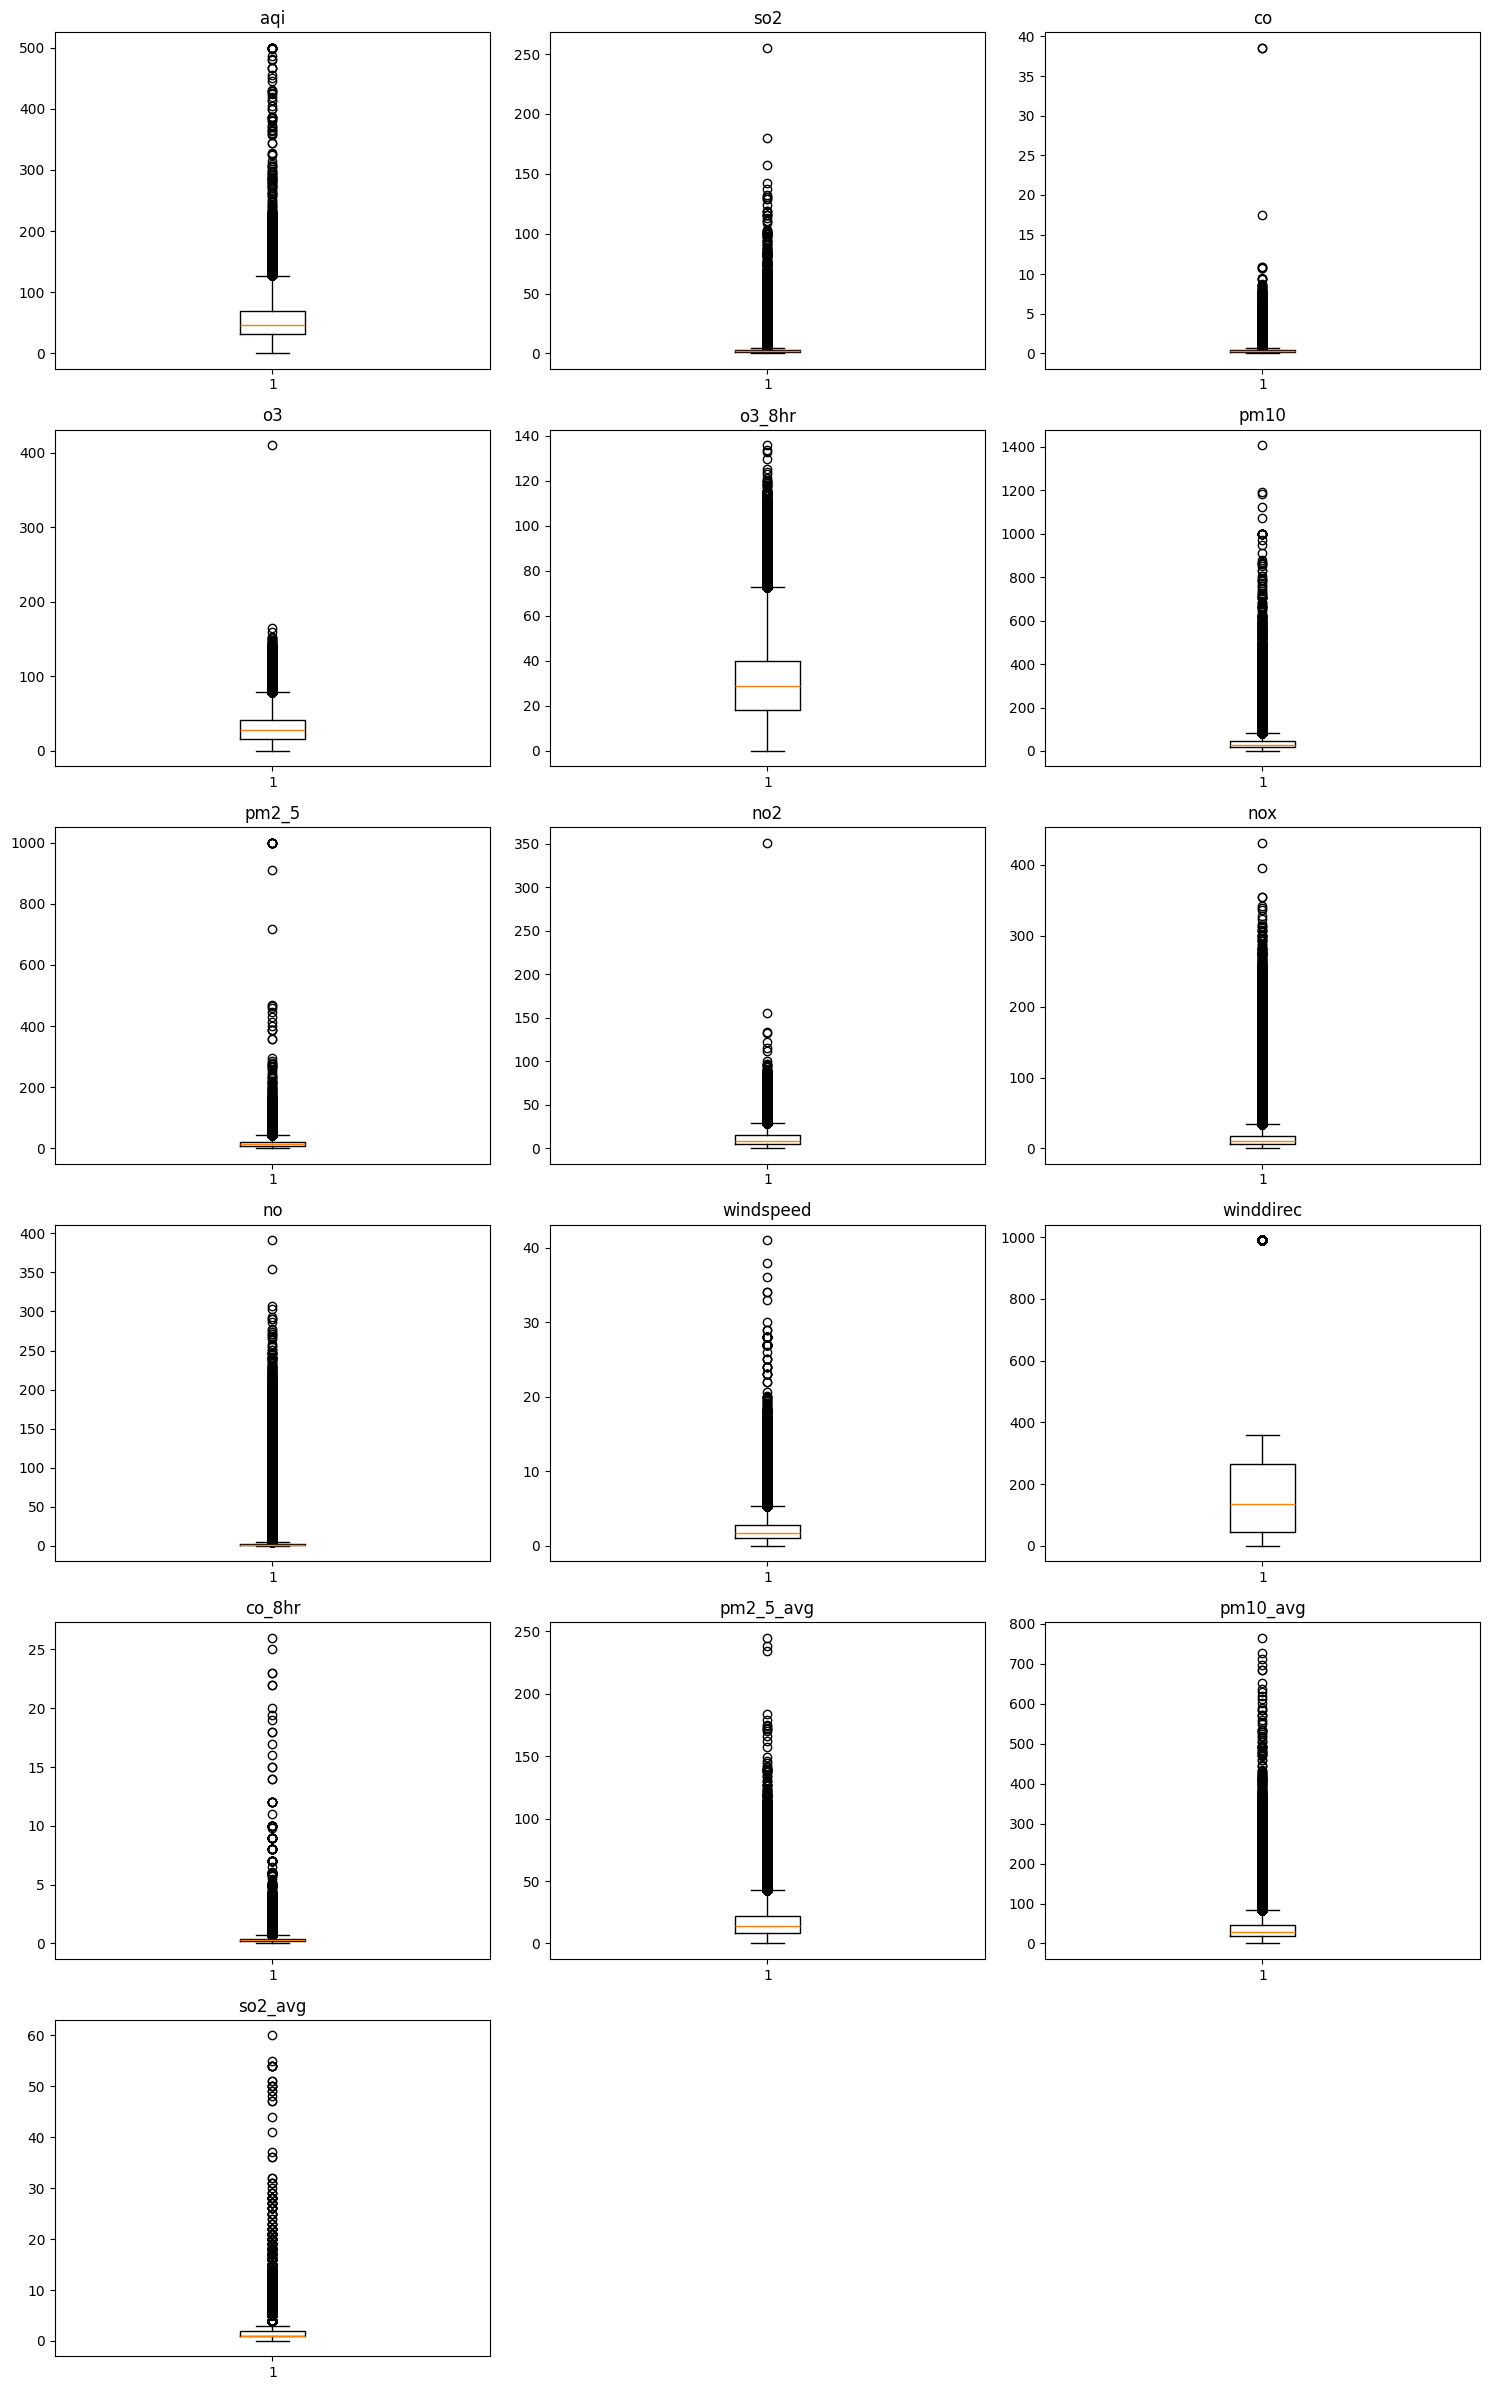

In [65]:
import math

cols = num_cols
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [66]:
outliers_dict = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outliers_dict[col] = len(outliers)

print(outliers_dict)

{'aqi': 171937, 'so2': 271505, 'co': 305690, 'o3': 71927, 'o3_8hr': 55702, 'pm10': 240099, 'pm2_5': 236731, 'no2': 252771, 'nox': 392855, 'no': 685782, 'windspeed': 306473, 'winddirec': 578, 'co_8hr': 234902, 'pm2_5_avg': 190079, 'pm10_avg': 184471, 'so2_avg': 375551}


In [67]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

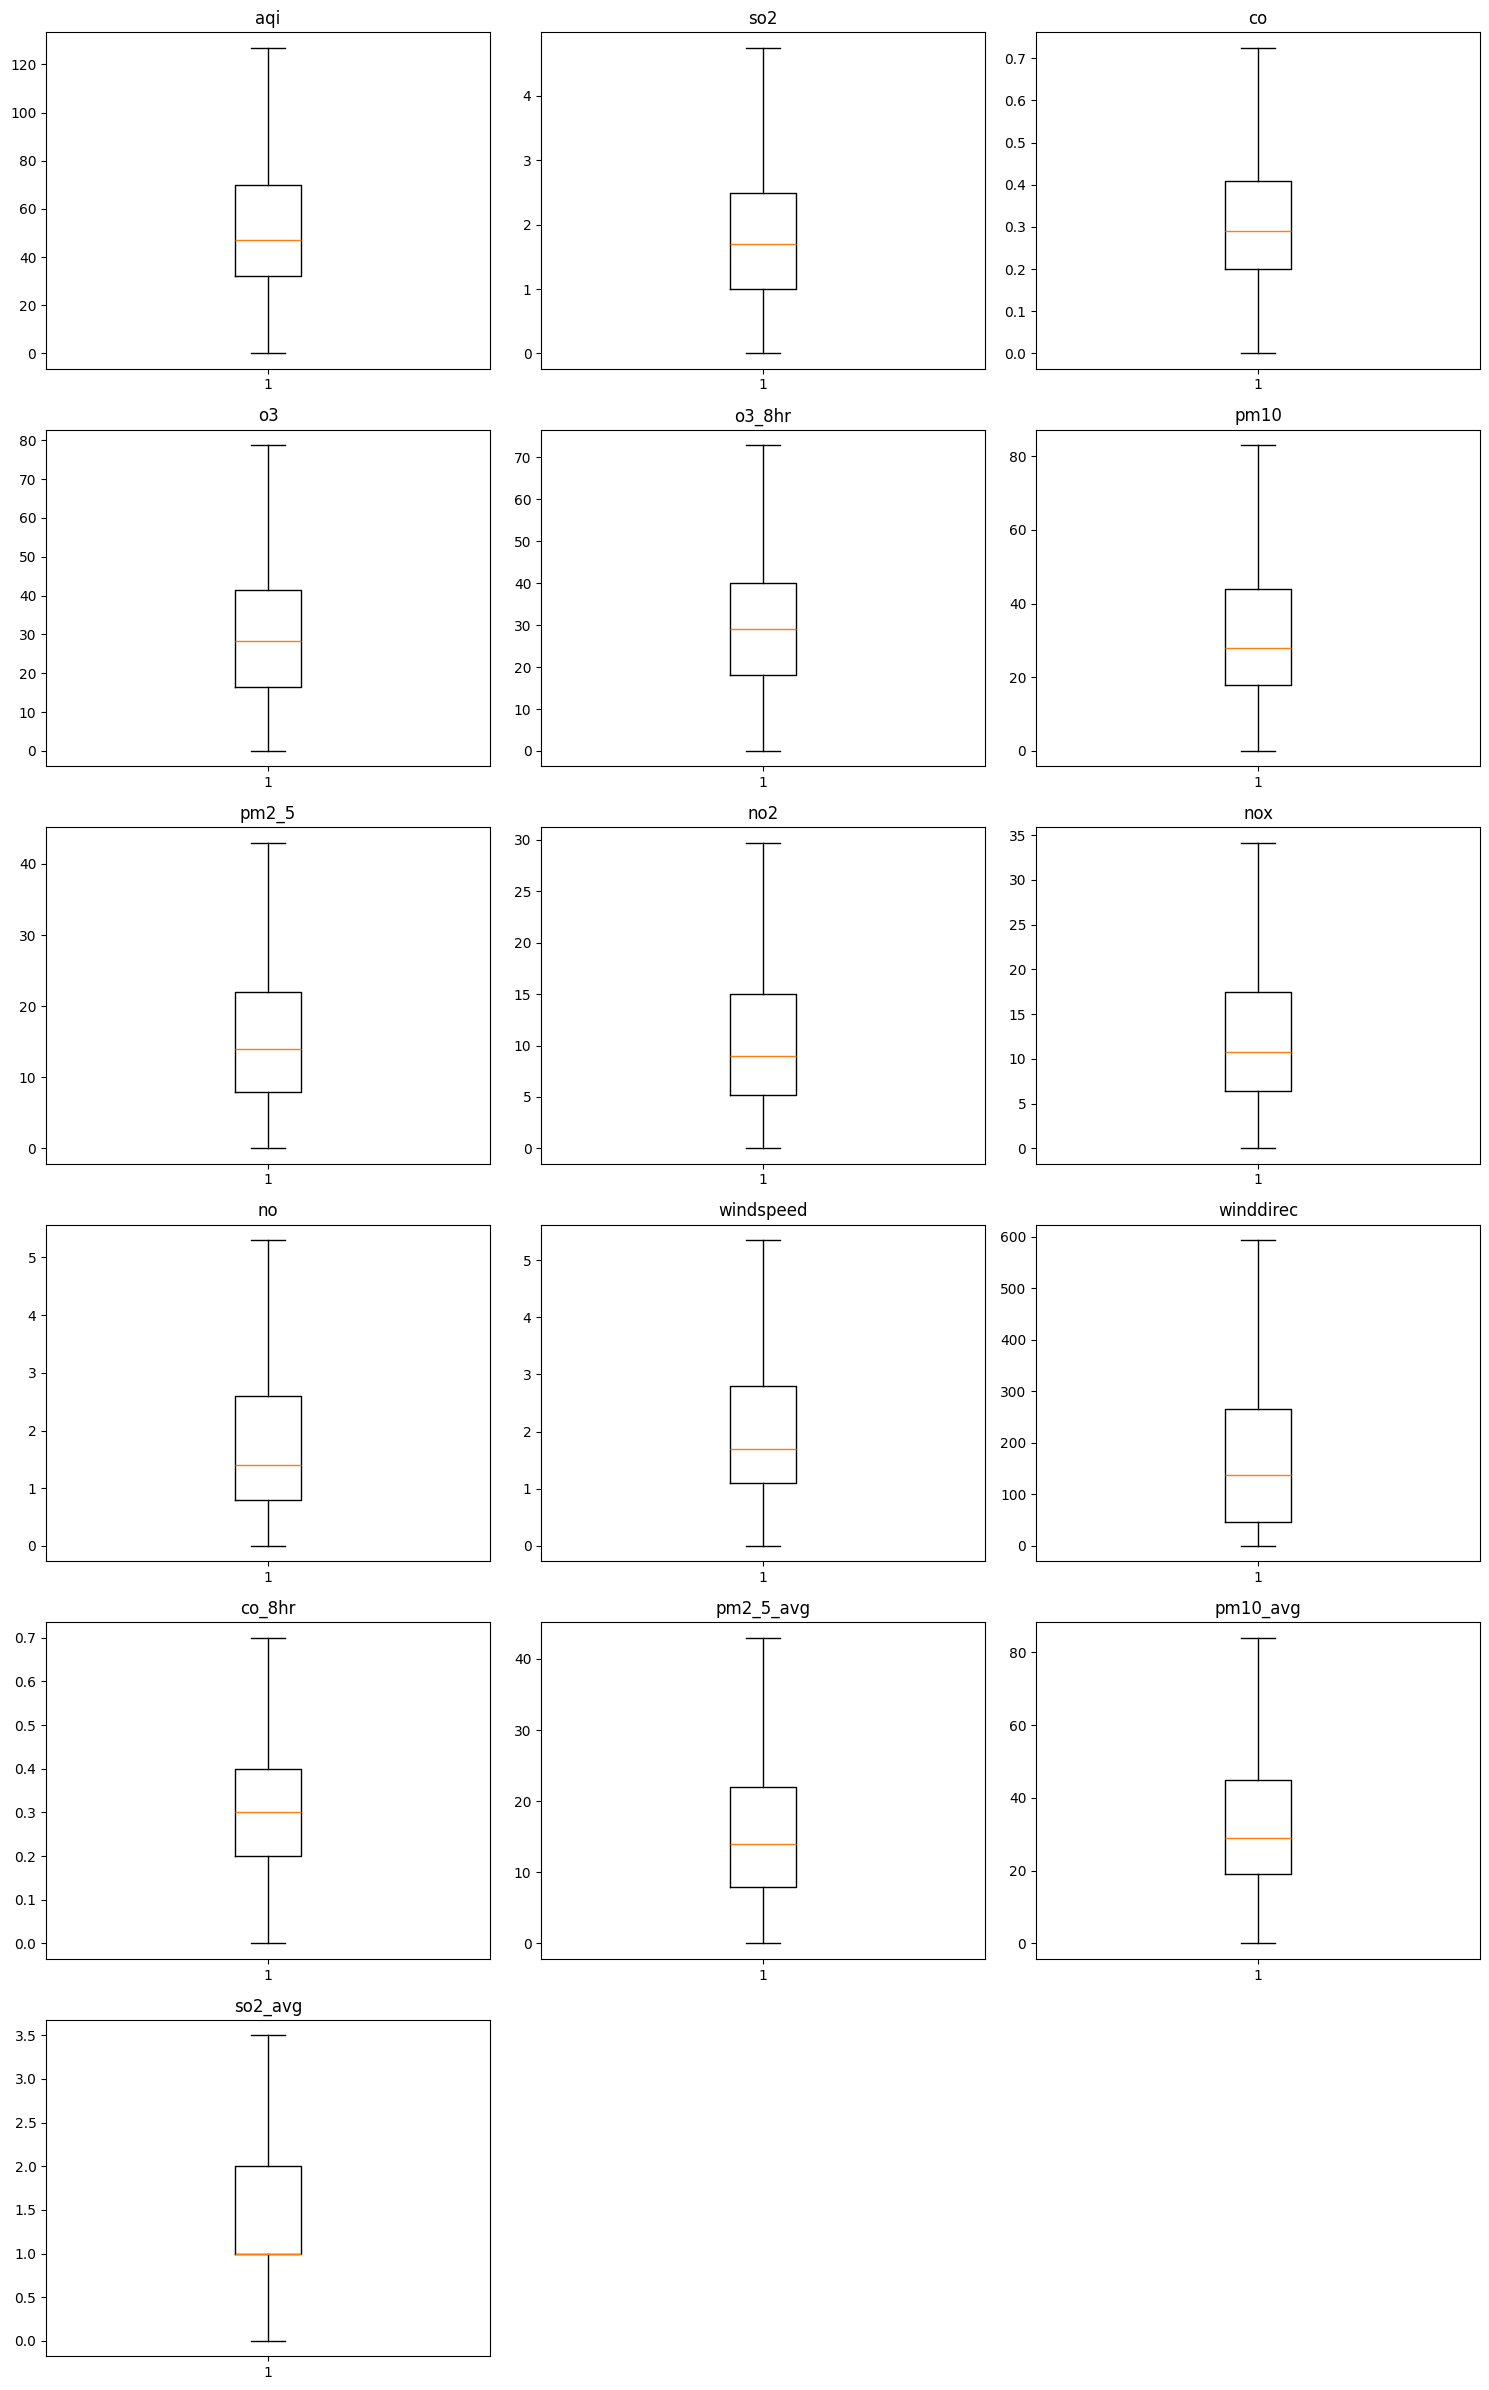

In [68]:
cols = num_cols
n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(15, n_rows * 4))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [69]:
df.duplicated().sum()

0

In [70]:
os.makedirs("models", exist_ok=True)
df.to_csv("models/cleaned_air_quality.csv",
index=False)

# ML

In [71]:
model_df = df.copy()

In [72]:
model_df[num_cols].corr()["aqi"].sort_values(ascending=False)

aqi          1.000000
pm2_5_avg    0.956142
pm2_5        0.869609
pm10_avg     0.867995
pm10         0.799389
co_8hr       0.502833
co           0.462920
no2          0.362012
o3_8hr       0.355607
so2          0.352741
so2_avg      0.309351
nox          0.301393
o3           0.296491
winddirec    0.091474
no           0.027376
windspeed   -0.023025
Name: aqi, dtype: float64

In [73]:
y = model_df["aqi"]
X = model_df.drop( columns=["aqi", "date","sitename","siteid", "county", "status","longitude","latitude"], errors="ignore" )

In [74]:
numerical_features = X.select_dtypes( include=["int64", "float64", "int32", "float32"] ).columns.tolist()
numerical_features

['so2',
 'co',
 'o3',
 'o3_8hr',
 'pm10',
 'pm2_5',
 'no2',
 'nox',
 'no',
 'windspeed',
 'winddirec',
 'co_8hr',
 'pm2_5_avg',
 'pm10_avg',
 'so2_avg']

In [75]:
joblib.dump(X.columns.tolist(),"models/model_features.pkl")

['models/model_features.pkl']

## train test split(Darin Ashraf)

In [76]:
from sklearn.model_selection import train_test_split

In [77]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 )

## Modeling(Darin Ashraf - Mariam Gamal)

In [78]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42
        )
}


In [79]:
results = []

trained_models = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )

    r2 = r2_score(
        y_test,
        prediction
    )

    results.append({

        "Model": name,

        "MAE": mae,

        "RMSE": rmse,

        "R2 Score": r2

    })

    trained_models[name] = model

results = pd.DataFrame(results)

results = results.sort_values(
    by="R2 Score",
    ascending=False
)

results


,Model,MAE,RMSE,R2 Score
1,Decision Tree,0.931828,2.726437,0.990606
0,Linear Regression,4.652925,6.952903,0.938906


In [80]:
best_model_name = results.iloc[0]["Model"]

print("Best Model :", best_model_name)

best_model = trained_models[best_model_name]


Best Model : Decision Tree


In [81]:
prediction = best_model.predict(X_test)


comparison = pd.DataFrame({

    "Actual": y_test,

    "Predicted": prediction

})

comparison.head()


,Actual,Predicted
869711,15.0,15.0
1215216,112.0,113.0
1037616,30.0,28.0
4473511,28.0,29.0
1486776,32.0,32.0


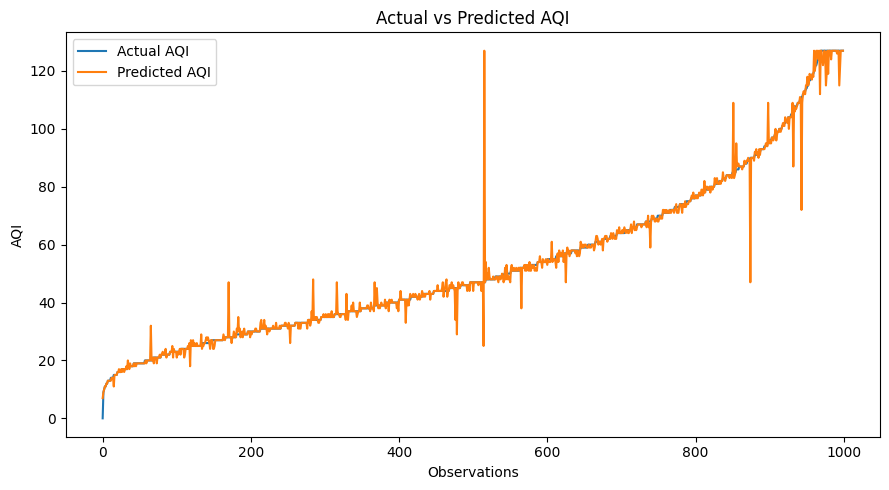

In [82]:
plot_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": prediction
})

plot_df = plot_df.sort_values("actual")

plot_df = plot_df.iloc[
    np.linspace(0, len(plot_df) - 1, 1000).astype(int)
]

plt.figure(figsize=(9, 5))

plt.plot(
    plot_df["actual"].values,
    label="Actual AQI"
)

plt.plot(
    plot_df["predicted"].values,
    label="Predicted AQI"
)

plt.xlabel("Observations")
plt.ylabel("AQI")
plt.title("Actual vs Predicted AQI")
plt.legend()

plt.tight_layout()
plt.show()

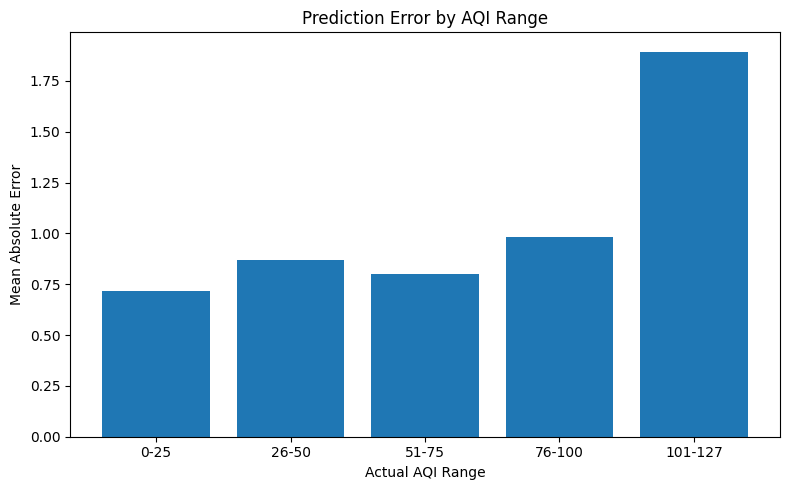

In [83]:

eval_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": prediction
})

eval_df["error"] = abs(
    eval_df["actual"] - eval_df["predicted"]
)

bins = [0, 25, 50, 75, 100, 127]

labels = [
    "0-25",
    "26-50",
    "51-75",
    "76-100",
    "101-127"
]

eval_df["aqi_range"] = pd.cut(
    eval_df["actual"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

mae_by_range = (
    eval_df
    .groupby("aqi_range", observed=False)["error"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    mae_by_range.index.astype(str),
    mae_by_range.values
)

plt.xlabel("Actual AQI Range")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction Error by AQI Range")

plt.tight_layout()
plt.show()



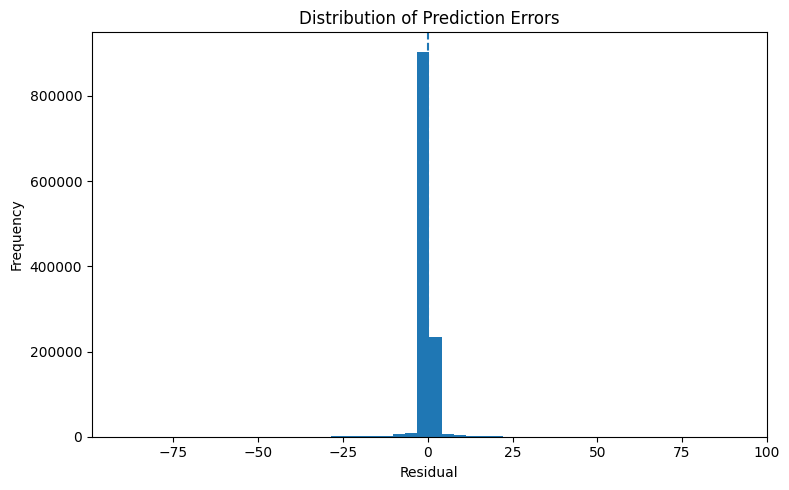

In [84]:
residuals = prediction - y_test

plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=50
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

In [85]:
joblib.dump(best_model,"models/best_model.pkl")
joblib.dump(
    best_model_name,
    "models/best_model_name.pkl"
)

['models/best_model_name.pkl']

In [86]:
results.to_csv("models/model_results.csv", index=False )

In [87]:
evaluation_data = pd.DataFrame({ "actual": y_test.values, "predicted": prediction }) 
evaluation_data.to_csv( "models/evaluation_data.csv", index=False )